# Module M6.1 — Comprehensive Model Evaluation & Final Model Selection

**Project:** Explainable and Bias-Aware ML for Phishing Website Detection  
**Roadmap ref:** Phase 6 → Module M6.1  

### Evaluation pipeline
1. Load all 8 trained models from `outputs/models/`  
2. Compute 9 metrics per model (Accuracy, Precision, Recall, F1, ROC AUC,  
   PR AUC, MCC, Balanced Accuracy, Brier Score)  
3. Generate confusion matrices, ROC curves, PR curves, calibration diagrams  
4. Select FINAL_DEPLOYMENT_MODEL (Track B winner by ROC AUC → F1 → Calibration)  
5. Export all downstream interface objects  


## 0. Environment Setup

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path().resolve().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
print(f'Project root: {PROJECT_ROOT}')


Project root: C:\Users\admin\Desktop\VS CODE\Explainable-Bias-Aware-Phishing-Detection


In [2]:
import warnings
warnings.filterwarnings('ignore')

import numpy  as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.utils.logger                    import get_logger
from src.evaluation.evaluator            import (
    load_all_models_and_data, run_full_evaluation
)
from src.evaluation.metrics              import (
    compute_full_metrics, build_metrics_dataframe
)
from src.evaluation.confusion_analysis   import (
    plot_all_confusion_matrices, plot_combined_confusion_grid
)
from src.evaluation.roc_analysis         import (
    plot_combined_roc, plot_roc_all_tracks,
    plot_combined_pr, plot_auc_ranking
)
from src.evaluation.calibration_analysis import (
    plot_calibration_curves, plot_probability_distribution,
    plot_calibration_comparison, calibration_quality_score
)
from src.evaluation.model_selector       import (
    select_best_model, select_final_deployment_model,
    build_deployment_interface, print_selection_report
)
from src.evaluation.evaluation_report    import generate_html_report

logger = get_logger('notebook.06_model_evaluation')
sns.set_theme(style='whitegrid', font_scale=1.05)
plt.rcParams['figure.dpi'] = 120
print('Imports OK ✓')


Imports OK ✓


## 1. Path Configuration

In [3]:
MODELS_DIR    = PROJECT_ROOT / 'outputs' / 'models'
PROCESSED_DIR = PROJECT_ROOT / 'data'    / 'processed'
REPORTS_DIR   = PROJECT_ROOT / 'outputs' / 'reports'
PLOTS_BASE    = PROJECT_ROOT / 'outputs' / 'plots' / 'evaluation'

for p in [MODELS_DIR, REPORTS_DIR, PLOTS_BASE]:
    p.mkdir(parents=True, exist_ok=True)
for sub in ['confusion_matrices','roc','pr_curves','calibration']:
    (PLOTS_BASE / sub).mkdir(parents=True, exist_ok=True)

# Verify all 8 trained models exist
print('Checking trained models ...')
missing = []
for track in ['A','B']:
    for m in ['logistic_regression','random_forest','xgboost','lightgbm']:
        p = MODELS_DIR / f'track_{track}' / f'{m}.pkl'
        sym = '✓' if p.exists() else '✗ MISSING'
        if not p.exists(): missing.append(str(p))
        print(f'  {sym}  {p.relative_to(PROJECT_ROOT)}')
if missing:
    raise RuntimeError(f'Missing models: {missing} — run M5 notebook first')
print('All 8 models found ✓')


Checking trained models ...
  ✓  outputs\models\track_A\logistic_regression.pkl
  ✓  outputs\models\track_A\random_forest.pkl
  ✓  outputs\models\track_A\xgboost.pkl
  ✓  outputs\models\track_A\lightgbm.pkl
  ✓  outputs\models\track_B\logistic_regression.pkl
  ✓  outputs\models\track_B\random_forest.pkl
  ✓  outputs\models\track_B\xgboost.pkl
  ✓  outputs\models\track_B\lightgbm.pkl
All 8 models found ✓


## 2. Load Trained Models and Test Data

In [4]:
loaded = load_all_models_and_data(
    models_dir    = MODELS_DIR,
    processed_dir = PROCESSED_DIR,
)

models_A = loaded['models_A']
models_B = loaded['models_B']
X_test_A = loaded['X_test_A']
X_test_B = loaded['X_test_B']
y_test   = loaded['y_test']

print(f'Track A models : {list(models_A.keys())}')
print(f'Track B models : {list(models_B.keys())}')
print(f'X_test_A       : {X_test_A.shape}')
print(f'X_test_B       : {X_test_B.shape}')
print(f'y_test         : {len(y_test):,} labels')
print(f'Class balance  : phishing={int((y_test==0).sum()):,}  '
      f'legitimate={int((y_test==1).sum()):,}')


2026-06-17 20:58:29 | INFO     | src.evaluation.evaluator                 | Loading trained models ...
2026-06-17 20:58:29 | INFO     | src.training.model_saver                 | Model loaded ← C:\Users\admin\Desktop\VS CODE\Explainable-Bias-Aware-Phishing-Detection\outputs\models\track_A\logistic_regression.pkl
2026-06-17 20:58:29 | INFO     | src.training.model_saver                 | Model loaded ← C:\Users\admin\Desktop\VS CODE\Explainable-Bias-Aware-Phishing-Detection\outputs\models\track_A\random_forest.pkl
2026-06-17 20:58:29 | INFO     | src.training.model_saver                 | Model loaded ← C:\Users\admin\Desktop\VS CODE\Explainable-Bias-Aware-Phishing-Detection\outputs\models\track_A\xgboost.pkl
2026-06-17 20:58:29 | INFO     | src.training.model_saver                 | Model loaded ← C:\Users\admin\Desktop\VS CODE\Explainable-Bias-Aware-Phishing-Detection\outputs\models\track_A\lightgbm.pkl
2026-06-17 20:58:29 | INFO     | src.training.model_saver                 | Loaded

Track A models : ['logistic_regression', 'random_forest', 'xgboost', 'lightgbm']
Track B models : ['logistic_regression', 'random_forest', 'xgboost', 'lightgbm']
X_test_A       : (47074, 57)
X_test_B       : (47074, 56)
y_test         : 47,074 labels
Class balance  : phishing=20,104  legitimate=26,970


## 3. Full Evaluation (all 8 models × 9 metrics)

In [5]:
# Run the complete evaluation pipeline
# This generates all metrics, plots, and CSV reports automatically.
print('Running full evaluation ...')

eval_output = run_full_evaluation(
    models_dir    = MODELS_DIR,
    processed_dir = PROCESSED_DIR,
    reports_dir   = REPORTS_DIR,
    plots_dir     = PLOTS_BASE,
)

eval_results = eval_output['eval_results']
metrics_df   = eval_output['metrics_df']
error_df     = eval_output['error_df']

print(f'Evaluated {len(eval_results)} models')
print(f'Metrics shape: {metrics_df.shape}')


2026-06-17 20:58:31 | INFO     | src.evaluation.evaluator                 | =======================================================
2026-06-17 20:58:31 | INFO     | src.evaluation.evaluator                 | M6.1 — FULL MODEL EVALUATION
2026-06-17 20:58:31 | INFO     | src.evaluation.evaluator                 | =======================================================
2026-06-17 20:58:31 | INFO     | src.evaluation.evaluator                 | Loading trained models ...
2026-06-17 20:58:31 | INFO     | src.training.model_saver                 | Model loaded ← C:\Users\admin\Desktop\VS CODE\Explainable-Bias-Aware-Phishing-Detection\outputs\models\track_A\logistic_regression.pkl
2026-06-17 20:58:31 | INFO     | src.training.model_saver                 | Model loaded ← C:\Users\admin\Desktop\VS CODE\Explainable-Bias-Aware-Phishing-Detection\outputs\models\track_A\random_forest.pkl
2026-06-17 20:58:31 | INFO     | src.training.model_saver                 | Model loaded ← C:\Users\admin\Deskto

Running full evaluation ...


2026-06-17 20:58:31 | INFO     | src.training.model_saver                 | Model loaded ← C:\Users\admin\Desktop\VS CODE\Explainable-Bias-Aware-Phishing-Detection\outputs\models\track_B\random_forest.pkl
2026-06-17 20:58:31 | INFO     | src.training.model_saver                 | Model loaded ← C:\Users\admin\Desktop\VS CODE\Explainable-Bias-Aware-Phishing-Detection\outputs\models\track_B\xgboost.pkl
2026-06-17 20:58:31 | INFO     | src.training.model_saver                 | Model loaded ← C:\Users\admin\Desktop\VS CODE\Explainable-Bias-Aware-Phishing-Detection\outputs\models\track_B\lightgbm.pkl
2026-06-17 20:58:31 | INFO     | src.training.model_saver                 | Loaded 4/4 Track B models
2026-06-17 20:58:31 | INFO     | src.evaluation.evaluator                 |   Track A: 4 models  Track B: 4 models
2026-06-17 20:58:31 | INFO     | src.evaluation.evaluator                 | Loading test data ...
2026-06-17 20:58:32 | INFO     | src.evaluation.evaluator                 |   X_t

Evaluated 8 models
Metrics shape: (8, 20)


## 4. Metrics Comparison Table

In [6]:
display_cols = ['model','track','accuracy','precision','recall','f1',
                'roc_auc','pr_auc','mcc','balanced_accuracy','brier_score']
display(metrics_df[[c for c in display_cols if c in metrics_df.columns]])
print(f'\nSaved → outputs/reports/evaluation_metrics.csv')


,model,track,accuracy,precision,recall,f1,roc_auc,pr_auc,mcc,balanced_accuracy,brier_score
0,Logistic Regression,A,0.999958,0.999958,0.999958,0.999958,1.0,1.0,0.999913,0.999950,0.000031
1,Random Forest,A,1.000000,1.000000,1.000000,1.000000,1.0,1.0,1.000000,1.000000,0.000047
2,XGBoost,A,0.999958,0.999958,0.999958,0.999958,1.0,1.0,0.999913,0.999950,0.000042
3,LightGBM,A,1.000000,1.000000,1.000000,1.000000,1.0,1.0,1.000000,1.000000,0.000000
4,Logistic Regression,B,0.999936,0.999936,0.999936,0.999936,1.0,1.0,0.999870,0.999925,0.000083
5,Random Forest,B,0.999851,0.999851,0.999851,0.999851,1.0,1.0,0.999696,0.999839,0.000404
6,XGBoost,B,0.999894,0.999894,0.999894,0.999894,1.0,1.0,0.999783,0.999888,0.000078
7,LightGBM,B,0.999936,0.999936,0.999936,0.999936,1.0,1.0,0.999870,0.999932,0.000055



Saved → outputs/reports/evaluation_metrics.csv


## 5. Confusion Matrix Analysis

In [7]:
from src.evaluation.metrics import compute_error_metrics

print('TP / FP / FN / TN breakdown per model (Track B):')
b_results = [r for r in eval_results if r.get('track','')=='B']
for r in b_results:
    em = compute_error_metrics(r['y_true'], r['y_pred'])
    print(f"  {r['model']:<26}  "
          f"TP={em['tp']:>5,}  TN={em['tn']:>5,}  "
          f"FP={em['fp']:>5,}  FN={em['fn']:>5,}  "
          f"FPR={em['fpr']:.4f}  FNR={em['fnr']:.4f}")


TP / FP / FN / TN breakdown per model (Track B):
  Logistic Regression         TP=26,970  TN=20,101  FP=    3  FN=    0  FPR=0.0001  FNR=0.0000
  Random Forest               TP=26,968  TN=20,099  FP=    5  FN=    2  FPR=0.0002  FNR=0.0001
  XGBoost                     TP=26,968  TN=20,101  FP=    3  FN=    2  FPR=0.0001  FNR=0.0001
  LightGBM                    TP=26,969  TN=20,102  FP=    2  FN=    1  FPR=0.0001  FNR=0.0000


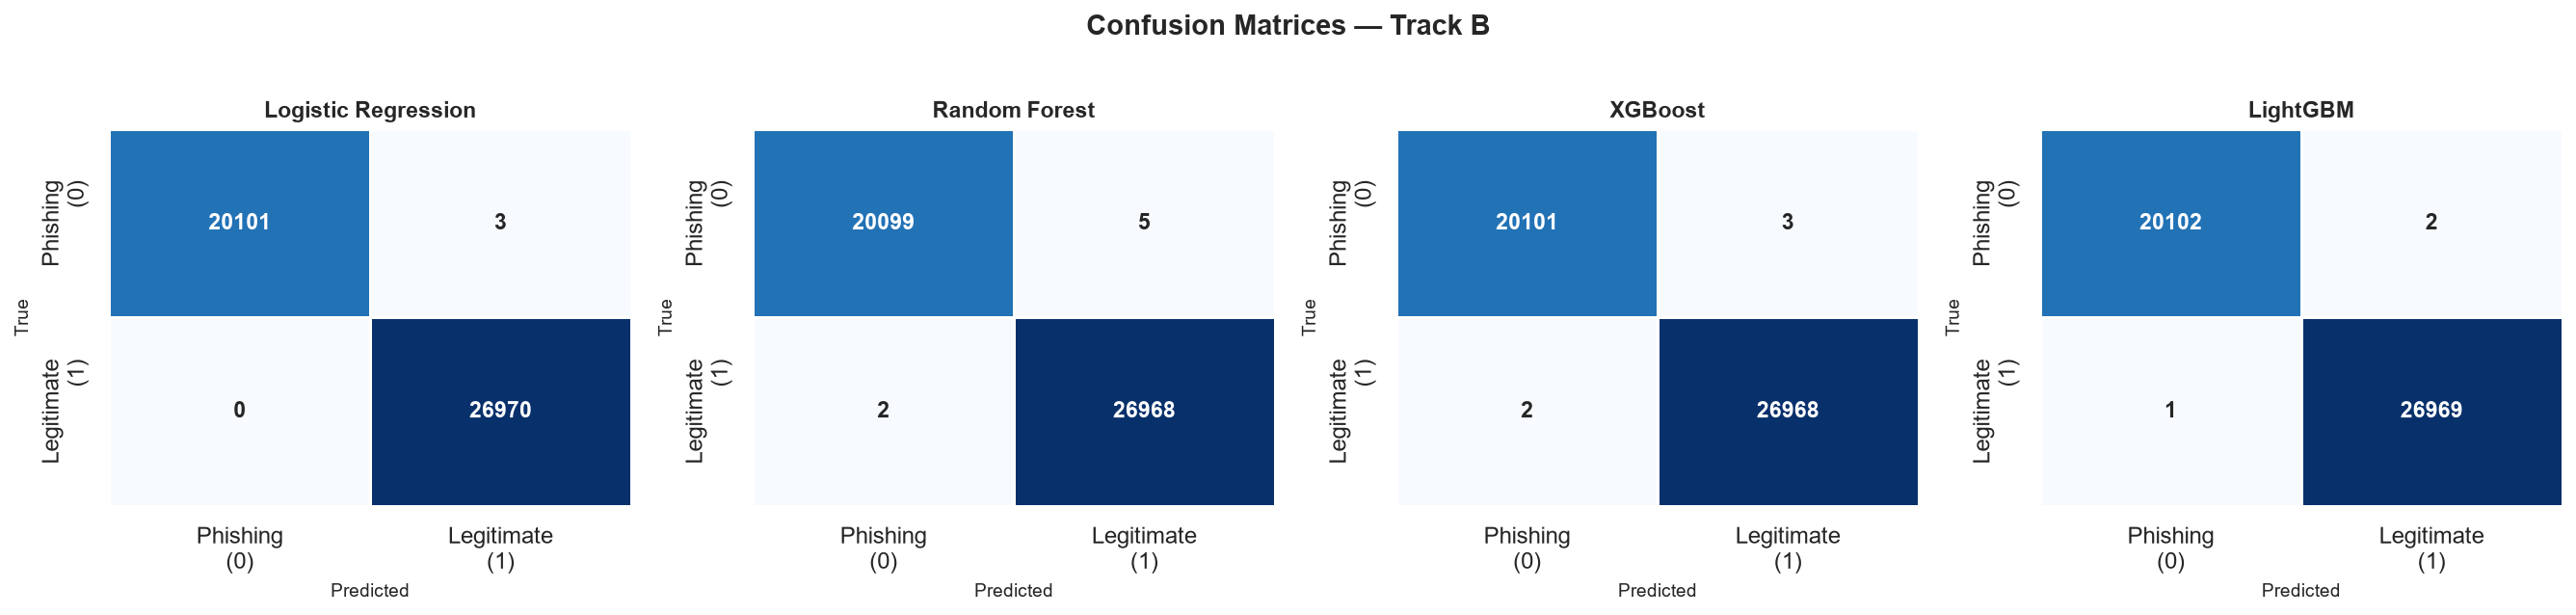

In [8]:
# Display combined CM grid for Track B
from IPython.display import Image
cm_grid_path = PLOTS_BASE / 'confusion_matrices' / 'cm_grid_trackB.png'
if cm_grid_path.exists():
    display(Image(str(cm_grid_path)))
else:
    print('CM grid not found — run evaluation first')


## 6. ROC Analysis

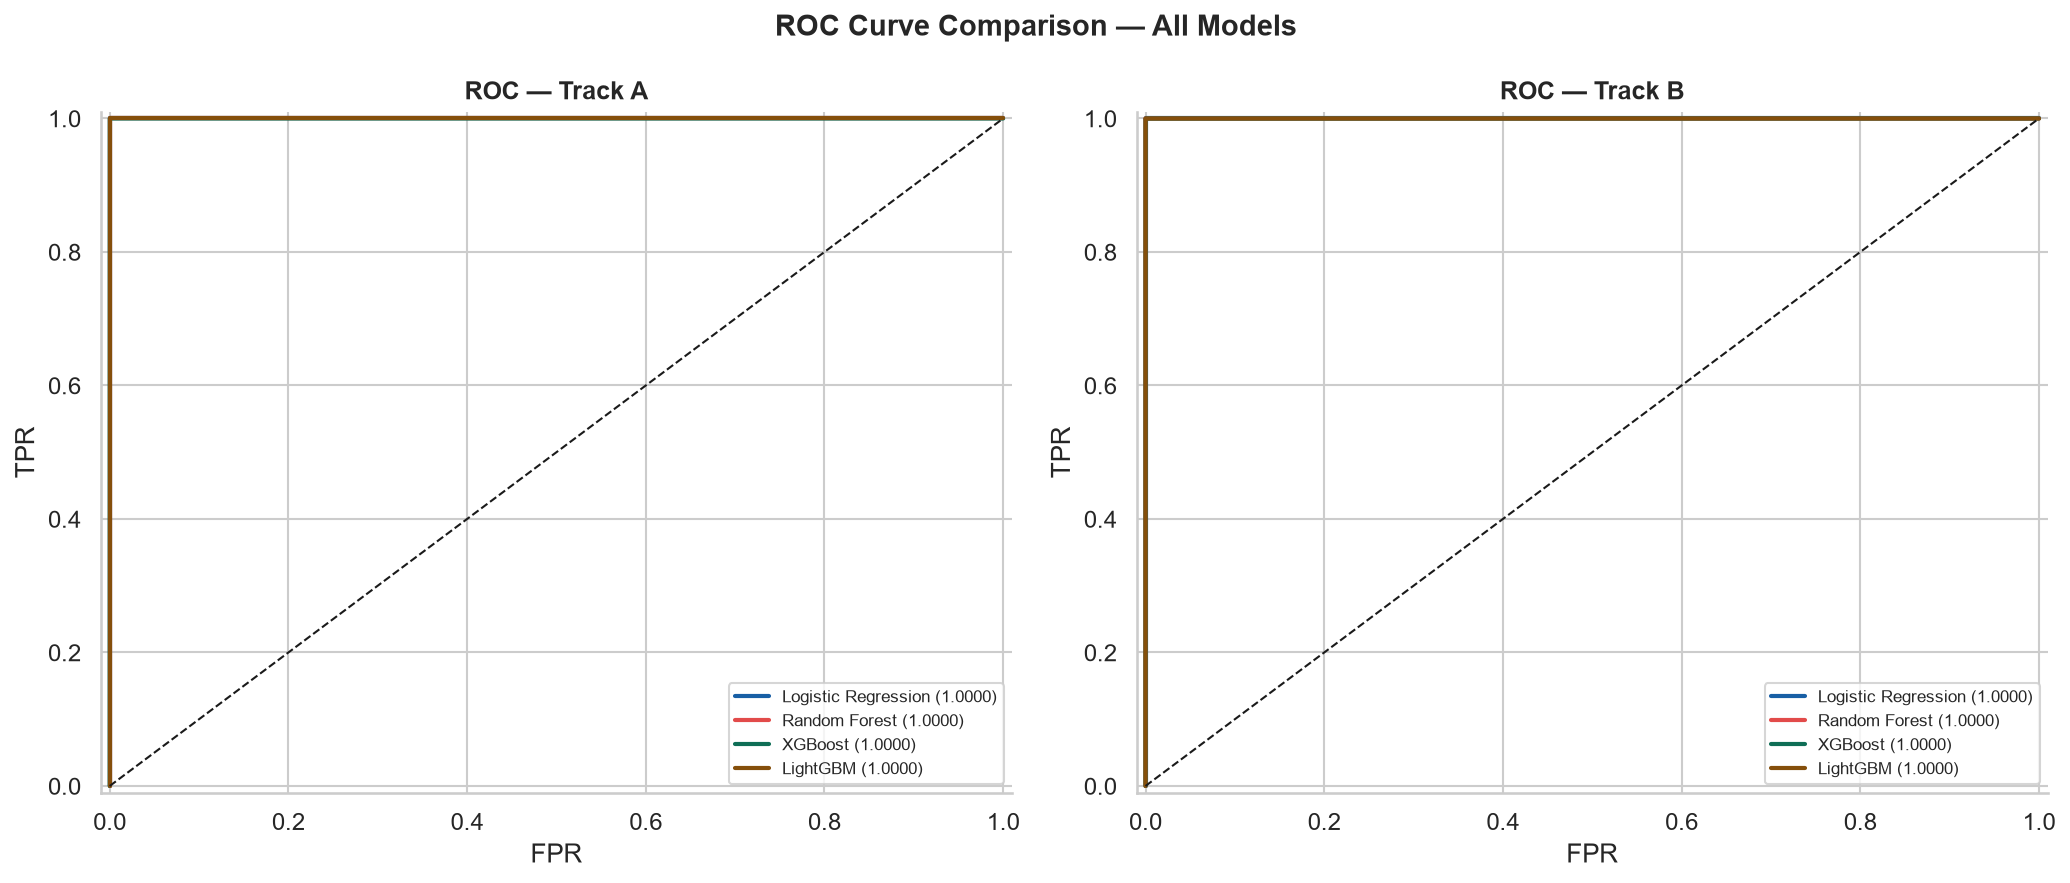


ROC AUC ranking (Track B):
              model  roc_auc  pr_auc
Logistic Regression      1.0     1.0
      Random Forest      1.0     1.0
            XGBoost      1.0     1.0
           LightGBM      1.0     1.0


In [9]:
from IPython.display import Image
roc_path = PLOTS_BASE / 'roc' / 'roc_all_tracks.png'
if roc_path.exists():
    display(Image(str(roc_path)))
else:
    print('ROC plot not found')

# Show ROC AUC ranking
print('\nROC AUC ranking (Track B):')
b_auc = metrics_df[metrics_df['track']=='B'][['model','roc_auc','pr_auc']]
print(b_auc.sort_values('roc_auc', ascending=False).to_string(index=False))


## 7. Precision-Recall Analysis

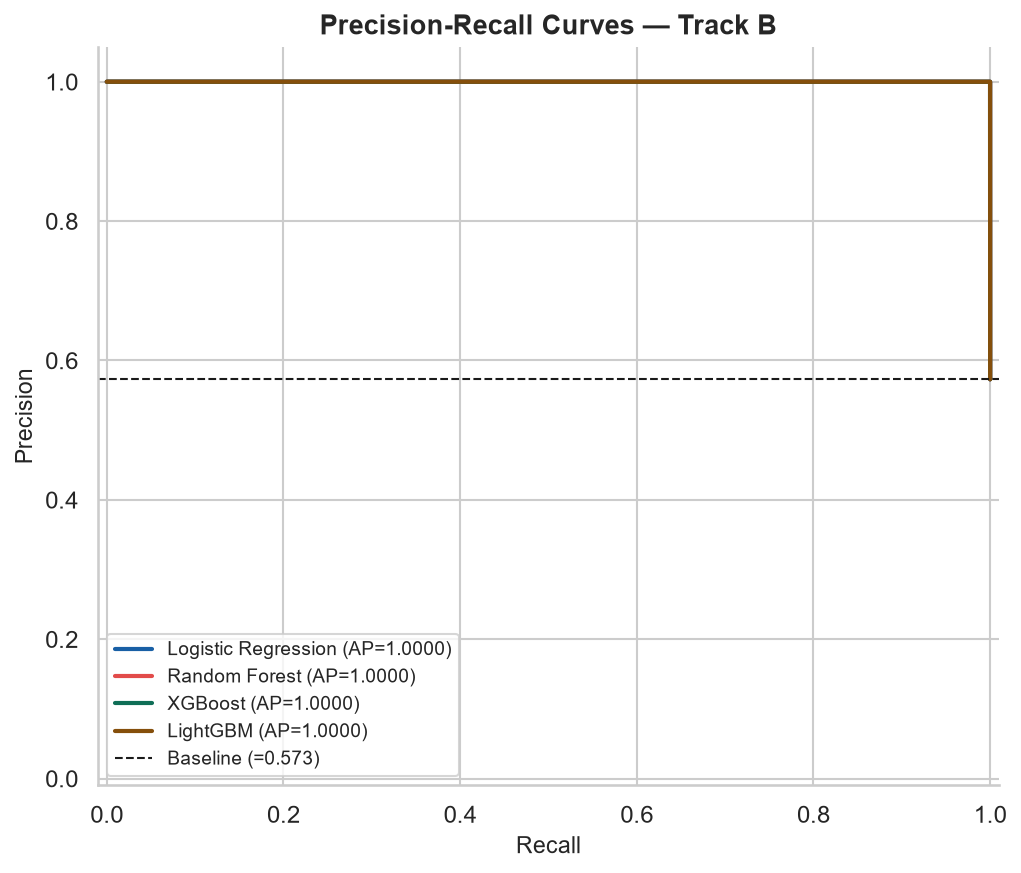

PR AUC ranking (Track B):
              model  roc_auc  pr_auc
Logistic Regression      1.0     1.0
      Random Forest      1.0     1.0
            XGBoost      1.0     1.0
           LightGBM      1.0     1.0


In [10]:
from IPython.display import Image
pr_path = PLOTS_BASE / 'pr_curves' / 'pr_trackB.png'
if pr_path.exists():
    display(Image(str(pr_path)))

print('PR AUC ranking (Track B):')
print(b_auc.sort_values('pr_auc', ascending=False).to_string(index=False))


## 8. Calibration Analysis

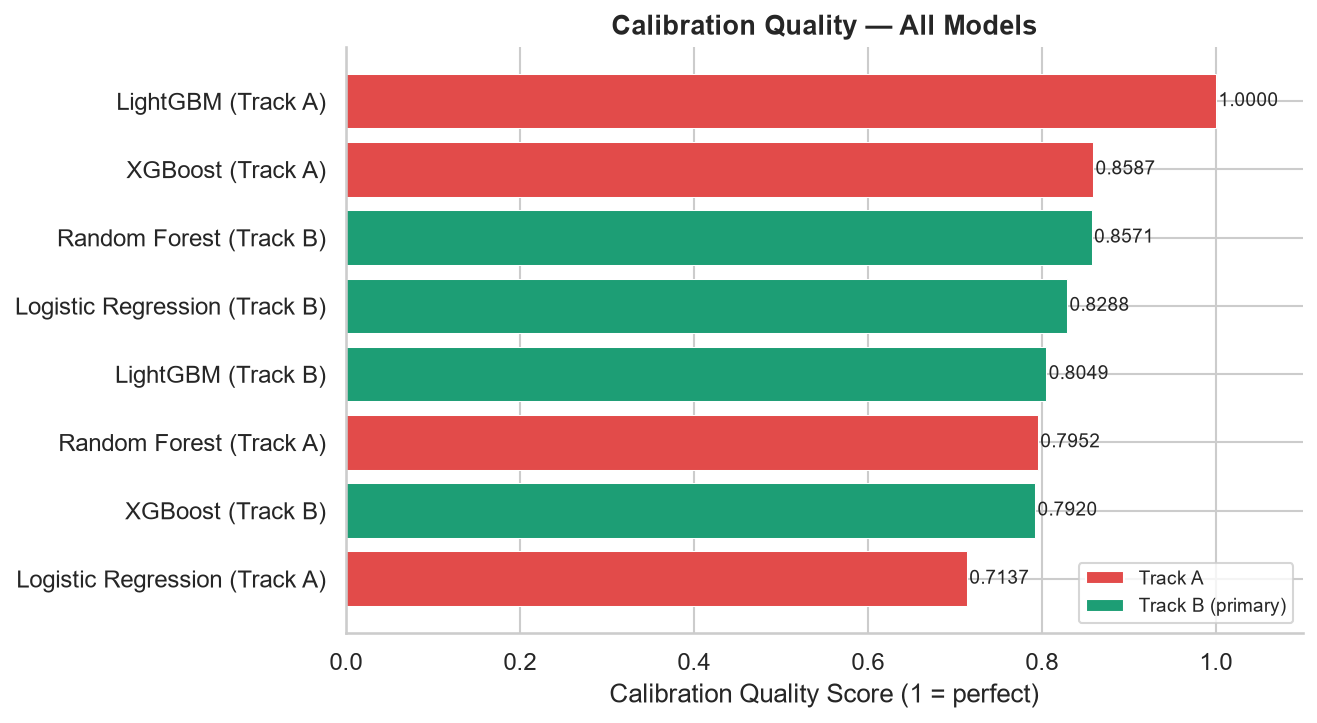

Calibration quality scores (Track B):


In [11]:
from IPython.display import Image
cal_path = PLOTS_BASE / 'calibration' / 'calibration_comparison.png'
if cal_path.exists():
    display(Image(str(cal_path)))

print('Calibration quality scores (Track B):')
if 'calibration_quality' in metrics_df.columns:
    cal_df = metrics_df[metrics_df['track']=='B'][['model','calibration_quality']]
    print(cal_df.sort_values('calibration_quality', ascending=False).to_string(index=False))


## 9. Error Analysis (FPR, FNR, Specificity, Sensitivity)

In [12]:
err_cols = ['model','track','fpr','fnr','specificity','sensitivity']
err_cols_present = [c for c in err_cols if c in error_df.columns]
display(error_df[err_cols_present])
print('\nSaved → outputs/reports/error_analysis.csv')


,model,track,fpr,fnr,specificity,sensitivity
0,Logistic Regression,A,0.000099,0.000000,0.999901,1.000000
1,Random Forest,A,0.000000,0.000000,1.000000,1.000000
2,XGBoost,A,0.000099,0.000000,0.999901,1.000000
3,LightGBM,A,0.000000,0.000000,1.000000,1.000000
4,Logistic Regression,B,0.000149,0.000000,0.999851,1.000000
5,Random Forest,B,0.000249,0.000074,0.999751,0.999926
6,XGBoost,B,0.000149,0.000074,0.999851,0.999926
7,LightGBM,B,0.000099,0.000037,0.999901,0.999963



Saved → outputs/reports/error_analysis.csv


In [13]:
# FNR insight: phishing sites missed (highest risk for security)
print('FNR comparison (lower = fewer missed phishing sites):')
if 'fnr' in metrics_df.columns:
    fnr_df = metrics_df[metrics_df['track']=='B'][['model','fnr','fpr']]
    fnr_df = fnr_df.sort_values('fnr')
    for _, row in fnr_df.iterrows():
        print(f"  {row['model']:<26}  FNR={row['fnr']:.4f}  FPR={row['fpr']:.4f}")


FNR comparison (lower = fewer missed phishing sites):
  Logistic Regression         FNR=0.0000  FPR=0.0001
  LightGBM                    FNR=0.0000  FPR=0.0001
  Random Forest               FNR=0.0001  FPR=0.0002
  XGBoost                     FNR=0.0001  FPR=0.0001


## 10. Model Ranking

In [14]:
print('=== COMPLETE RANKING TABLE (by ROC AUC) ===')
rank_df = metrics_df.sort_values(['track','roc_auc'], ascending=[True,False])
rank_cols = ['model','track','roc_auc','f1','mcc','brier_score']
rank_cols_p = [c for c in rank_cols if c in rank_df.columns]
print(rank_df[rank_cols_p].to_string(index=False))


=== COMPLETE RANKING TABLE (by ROC AUC) ===
              model track  roc_auc       f1      mcc  brier_score
Logistic Regression     A      1.0 0.999958 0.999913     0.000031
      Random Forest     A      1.0 1.000000 1.000000     0.000047
            XGBoost     A      1.0 0.999958 0.999913     0.000042
           LightGBM     A      1.0 1.000000 1.000000     0.000000
Logistic Regression     B      1.0 0.999936 0.999870     0.000083
      Random Forest     B      1.0 0.999851 0.999696     0.000404
            XGBoost     B      1.0 0.999894 0.999783     0.000078
           LightGBM     B      1.0 0.999936 0.999870     0.000055


## 11. Final Model Selection

In [15]:
selection = select_final_deployment_model(eval_results)
print_selection_report(selection)

FINAL_DEPLOYMENT_MODEL = selection['FINAL_DEPLOYMENT_MODEL']
print(f'\nFINAL_DEPLOYMENT_MODEL type : {type(FINAL_DEPLOYMENT_MODEL).__name__}')
print(f'deployment_model_name       : {selection["deployment_model_name"]}')
print(f'deployment_model_id         : {selection["deployment_model_id"]}')


2026-06-17 20:58:48 | INFO     | src.evaluation.model_selector            | Best Track A: LightGBM
2026-06-17 20:58:48 | INFO     | src.evaluation.model_selector            |   ROC AUC  : 1.000000
2026-06-17 20:58:48 | INFO     | src.evaluation.model_selector            |   F1 Score : 1.000000
2026-06-17 20:58:48 | INFO     | src.evaluation.model_selector            |   Calibrat : 0.999993
2026-06-17 20:58:48 | INFO     | src.evaluation.model_selector            |   Rationale: Highest ROC AUC on Track A test set: 1.000000 | Tie-broke by F1: 1.000000 | Calibration quality: 1.0000
2026-06-17 20:58:48 | INFO     | src.evaluation.model_selector            | Best Track B: Logistic Regression
2026-06-17 20:58:48 | INFO     | src.evaluation.model_selector            |   ROC AUC  : 1.000000
2026-06-17 20:58:48 | INFO     | src.evaluation.model_selector            |   F1 Score : 0.999936
2026-06-17 20:58:48 | INFO     | src.evaluation.model_selector            |   Calibrat : 0.828821
2026-06-17


FINAL_DEPLOYMENT_MODEL type : LogisticRegression
deployment_model_name       : Logistic Regression
deployment_model_id         : logistic_regression


## 12. Build Downstream Deployment Interface

In [16]:
interface = build_deployment_interface(selection, loaded)

print('=== DOWNSTREAM MODULE INTERFACE ===')
print()
print('M7.1 SHAP:')
print(f'  SHAP_model         : {type(interface["SHAP_model"]).__name__}')
print(f'  SHAP_X_train       : {interface["SHAP_X_train"].shape}')
print(f'  SHAP_X_test        : {interface["SHAP_X_test"].shape}')
print(f'  SHAP_feature_names : {len(interface["SHAP_feature_names"])} features')
print()
print('M8.1 LIME:')
print(f'  LIME_predict_fn    : {interface["LIME_predict_fn"]}')
print(f'  LIME_X_train_np    : {interface["LIME_X_train_np"].shape}')
print(f'  LIME_X_test_np     : {interface["LIME_X_test_np"].shape}')
print()
print('M9 Bias / M10 Blindspot:')
print(f'  BIAS_X_test        : {interface["BIAS_X_test"].shape}')
print(f'  BIAS_y_test        : {len(interface["BIAS_y_test"]):,} labels')
print(f'  BIAS_y_pred shape  : {interface["BIAS_y_pred"].shape}')
print(f'  BIAS_y_proba shape : {interface["BIAS_y_proba"].shape}')
print()
print(f'feature_names_B    : first 5 = {interface["feature_names_B"][:5]}')


2026-06-17 20:58:50 | INFO     | src.evaluation.model_selector            | Deployment interface assembled:
2026-06-17 20:58:50 | INFO     | src.evaluation.model_selector            |   FINAL_DEPLOYMENT_MODEL : Logistic Regression
2026-06-17 20:58:50 | INFO     | src.evaluation.model_selector            |   feature_names_B        : 56 features
2026-06-17 20:58:50 | INFO     | src.evaluation.model_selector            |   SHAP_X_train shape     : (188296, 56)
2026-06-17 20:58:50 | INFO     | src.evaluation.model_selector            |   SHAP_X_test  shape     : (47074, 56)


=== DOWNSTREAM MODULE INTERFACE ===

M7.1 SHAP:
  SHAP_model         : LogisticRegression
  SHAP_X_train       : (188296, 56)
  SHAP_X_test        : (47074, 56)
  SHAP_feature_names : 56 features

M8.1 LIME:
  LIME_predict_fn    : <bound method LogisticRegression.predict_proba of LogisticRegression(class_weight='balanced', max_iter=1000, n_jobs=-1,
                   penalty='l2', random_state=42, solver='liblinear')>
  LIME_X_train_np    : (188296, 56)
  LIME_X_test_np     : (47074, 56)

M9 Bias / M10 Blindspot:
  BIAS_X_test        : (47074, 56)
  BIAS_y_test        : 47,074 labels
  BIAS_y_pred shape  : (47074,)
  BIAS_y_proba shape : (47074,)

feature_names_B    : first 5 = ['URLLength', 'DomainLength', 'TLDLength', 'TLD', 'IsDomainIP']


## 13. Generate Evaluation Report

In [17]:
report_path = generate_html_report(
    eval_results = eval_results,
    metrics_df   = metrics_df,
    selection    = selection,
    output_path  = REPORTS_DIR / 'model_evaluation_report.html',
    plots_dir    = PLOTS_BASE,
)
print(f'Report saved: {report_path}')


2026-06-17 20:58:50 | INFO     | src.evaluation.evaluation_report         | Evaluation report saved: C:\Users\admin\Desktop\VS CODE\Explainable-Bias-Aware-Phishing-Detection\outputs\reports\model_evaluation_report.html


Report saved: C:\Users\admin\Desktop\VS CODE\Explainable-Bias-Aware-Phishing-Detection\outputs\reports\model_evaluation_report.html


## 14. Artifact Verification

In [18]:
print('=== M6.1 OUTPUT ARTIFACTS ===')
artifacts = [
    'outputs/reports/evaluation_metrics.csv',
    'outputs/reports/error_analysis.csv',
    'outputs/reports/model_evaluation_report.html',
    'outputs/plots/evaluation/confusion_matrices/cm_grid_trackB.png',
    'outputs/plots/evaluation/roc/roc_all_tracks.png',
    'outputs/plots/evaluation/roc/auc_ranking.png',
    'outputs/plots/evaluation/pr_curves/pr_trackB.png',
    'outputs/plots/evaluation/calibration/calibration_comparison.png',
]
import pathlib
for rel in artifacts:
    p = PROJECT_ROOT / rel
    print(f"  {'✓' if p.exists() else '✗'}  {rel}")


=== M6.1 OUTPUT ARTIFACTS ===
  ✓  outputs/reports/evaluation_metrics.csv
  ✓  outputs/reports/error_analysis.csv
  ✓  outputs/reports/model_evaluation_report.html
  ✓  outputs/plots/evaluation/confusion_matrices/cm_grid_trackB.png
  ✓  outputs/plots/evaluation/roc/roc_all_tracks.png
  ✓  outputs/plots/evaluation/roc/auc_ranking.png
  ✓  outputs/plots/evaluation/pr_curves/pr_trackB.png
  ✓  outputs/plots/evaluation/calibration/calibration_comparison.png


## 15. Conclusions & Downstream Handoff

In [19]:
print('=' * 65)
print('MODULE M6.1 COMPLETE')
print('=' * 65)
print()
print(f"FINAL_DEPLOYMENT_MODEL    : {selection['deployment_model_name']}")
print(f"  Track B ROC AUC         : {selection['best_B']['primary_score']:.6f}")
print(f"  Track B F1              : {selection['best_B']['secondary_score']:.6f}")
print(f"  Calibration quality     : {selection['best_B']['tertiary_score']:.4f}")
print(f"  Leakage impact (A-B)    : {selection.get('leakage_impact_auc',0):+.6f}")
print()
print('Ready for downstream modules:')
print('  M7.1 SHAP    — SHAP_model, SHAP_X_train, SHAP_X_test, SHAP_feature_names')
print('  M8.1 LIME    — LIME_predict_fn, LIME_X_train_np, LIME_X_test_np, LIME_feature_names')
print('  M9  Bias     — BIAS_model, BIAS_X_test, BIAS_y_test, BIAS_y_pred, BIAS_y_proba')
print('  M10 Blindspot — same as Bias + BLINDSPOT_y_proba')
print()
print('Next: M7.1 — SHAP Explainability Analysis')


MODULE M6.1 COMPLETE

FINAL_DEPLOYMENT_MODEL    : Logistic Regression
  Track B ROC AUC         : 1.000000
  Track B F1              : 0.999936
  Calibration quality     : 0.8288
  Leakage impact (A-B)    : +0.000000

Ready for downstream modules:
  M7.1 SHAP    — SHAP_model, SHAP_X_train, SHAP_X_test, SHAP_feature_names
  M8.1 LIME    — LIME_predict_fn, LIME_X_train_np, LIME_X_test_np, LIME_feature_names
  M9  Bias     — BIAS_model, BIAS_X_test, BIAS_y_test, BIAS_y_pred, BIAS_y_proba
  M10 Blindspot — same as Bias + BLINDSPOT_y_proba

Next: M7.1 — SHAP Explainability Analysis
